Hi, this is a test text with an equation: $a=b$

In [1]:

%matplotlib widget



In [16]:
import sys
print(sys.executable)


/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/venv/bin/python


In [17]:
# Notebook Cell 1 – Setup
%matplotlib inline
import importlib
import os
import numpy as np
import pandas as pd
from datetime import date
import field
import plotting_HK

importlib.reload(field)
importlib.reload(plotting_HK)
from field import Field
from plotting_HK import plot_segment



In [18]:
# Notebook Cell 2 – Load your test field
filename = "/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/SimpleTestField.json"
filename1 = "/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/FieldID_2392761.json"

field1= Field(filename1)


gaps 14     1.98
15     2.69
16     4.22
17     7.34
18     8.75
19    12.18
20    13.56
21    14.31
22    14.87
23    15.12
24    12.44
25     9.40
26     8.76
27    10.13
28    11.52
29    12.38
30    14.03
31    14.82
32    14.68
33    14.47
34    14.19
35    13.72
36    13.27
37    12.57
38    12.18
39    11.55
40     8.95
41     9.34
42     9.81
43     9.70
44     9.29
45     7.36
46     6.65
47     6.70
48     6.22
49     6.27
50     5.20
51     4.87
52     5.32
53     4.21
54     4.02
55     3.97
56     4.79
57     5.05
58     4.87
59     4.53
60     4.15
61     3.32
62     2.34
63     0.69
64     0.40
Name: 179, dtype: float64
gaps 14     2.14
15     2.72
16     5.36
17     7.33
18     8.68
19    12.63
20    13.70
21    14.39
22    14.82
23    14.88
24    13.18
25     9.82
26     9.61
27    10.29
28    11.30
29    11.86
30    12.85
31    14.00
32    14.24
33    14.26
34    14.20
35    13.67
36    13.26
37    11.65
38    12.02
39    11.87
40     9.49
41     9.74
42     9.90
43  

In [14]:
# Notebook Cell 3 – Extract areas
Aside = field1.matrixA
BSide = field1.matrixB
leafgaps = Aside + BSide

leaf_widths = np.array(field1.leaf_width[leafgaps.index.min()-1: leafgaps.index.max()])
areas = leafgaps.mul(leaf_widths[:, np.newaxis])





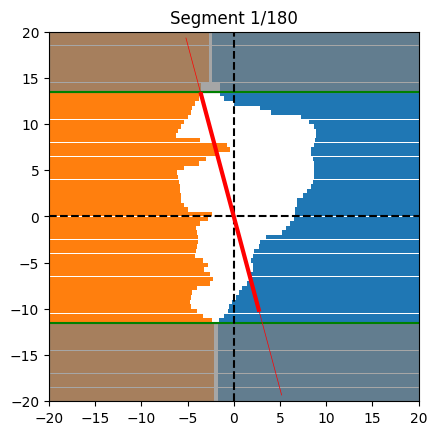

🟢 Collimator Angle: 15
 Total Beam MU: 686.7

 MU per Control Point:
179    0.000000
177    0.432621
175    0.439488
173    0.432621
171    0.439488
         ...   
189    2.259243
187    1.847223
185    1.242927
183    0.981981
181    1.064385
Length: 180, dtype: float64

 Sum of segment MU (should equal beam_meterset):
686.7

 Normalized MU weights (mu_weights):
179    0.00000
177    0.00063
175    0.00064
173    0.00063
171    0.00064
        ...   
189    0.00329
187    0.00269
185    0.00181
183    0.00143
181    0.00155
Length: 180, dtype: float64

 Sum of weights (should be 1):
0.9999999999999999
686.7

 gantry:


In [19]:
# Notebook Cell 4 – Plot one segment and show other info
segmentno = 0
plot_segment(field1, segmentno)



print("🟢 Collimator Angle:", field1.collimatorAngle)

# Test the MU assignment
print(" Total Beam MU:", field1.beam_meterset)
print("\n MU per Control Point:")
print(field1.aperture_ms)

print("\n Sum of segment MU (should equal beam_meterset):")
print(field1.aperture_ms.sum())

print("\n Normalized MU weights (mu_weights):")
print(field1.mu_weights)
#print("\n span :")
#print(field.cp[segmentno]['spanMin'], "to", field.cp[segmentno]['spanMax'])

print("\n Sum of weights (should be 1):")
print(field1.mu_weights.sum())
print(field1.beam_meterset)
print("\n gantry:")
#print(field1.gantry_total_areas)
#print(field.span)



In [20]:
print(field1.span)
print(len(field1.cp))
print(field1.matrixA)



[np.float64(24.156938929776963), np.float64(24.389876070369233), np.float64(24.376935118114105), np.float64(24.451992641193836), np.float64(24.50893283111639), np.float64(24.849545269454538), np.float64(24.906485459377095), np.float64(24.984131172907848), np.float64(25.002248506065023), np.float64(25.147187171322436), np.float64(25.224832884853193), np.float64(25.504357453563916), np.float64(25.74505916550926), np.float64(25.77094107001951), np.float64(25.688118975586704), np.float64(25.53800392942724), np.float64(25.579414976643648), np.float64(25.548356691231344), np.float64(25.628590595213126), np.float64(25.698471737390804), np.float64(25.817528498137968), np.float64(25.739882784607207), np.float64(25.56647402438852), np.float64(25.341301455149328), np.float64(25.380124311914706), np.float64(25.602708690702872), np.float64(25.6570606901744), np.float64(25.747647355960282), np.float64(25.55094488168237), np.float64(25.27918488432472), np.float64(25.186010028087814), np.float64(25.67

In [97]:
cp_idx = 0
start = field1.exposed_leaf_start[cp_idx]
end = field1.exposed_leaf_end[cp_idx]
gantry_angle = field1.matrixA.columns[cp_idx]
yvals = field1.leafblade_positions[::-1][start - 1:end]
xvalsA = field1.matrixA.loc[start:end, gantry_angle]
print(yvals)

from math import sin, cos, radians
import numpy as np

# Example y-values for exposed leaves (Atip) – 38 leaves
Atip = yvals

xvalsA = [1.0] * len(Atip)
xvalsB = [1.0] * len(Atip)  # Will flip sign later for Bank B

collimator_angle = 15
angle_rad = radians(-collimator_angle)
unit_vector = np.array([sin(angle_rad), cos(angle_rad)])


tipsA = list(zip(xvalsA, Atip))
tipsB = list(zip([-x for x in xvalsB], Atip)) 
print(tipsA)

dotsA = [np.dot(tip, unit_vector) for tip in tipsA]
print(dotsA)
dotsB = [np.dot(tip, unit_vector) for tip in tipsB]
print(dotsB)


# Combine both banks' projections to find the full aperture extent
all_projected_tips = dotsA + dotsB
print("projected tips",all_projected_tips)
# Calculate span
aperture_min = min(dotsA + dotsB)
print("Span Min:", aperture_min)

aperture_max = max(dotsA + dotsB)
print("Span Max:", aperture_max)

span = aperture_max - aperture_min
print("Span:", span)
print(field1.span)


[13.25, 12.75, 12.25, 11.75, 11.25, 10.75, 10.25, 9.75, 9.25, 8.75, 8.25, 7.75, 7.25, 6.75, 6.25, 5.75, 5.25, 4.75, 4.25, 3.75, 3.25, 2.75, 2.25, 1.75, 1.25, 0.75, 0.25, -0.25, -0.75, -1.25, -1.75, -2.25, -2.75, -3.25, -3.75, -4.25, -4.75, -5.25, -5.75, -6.25, -6.75, -7.25, -7.75, -8.25, -8.75, -9.25, -9.75, -10.25, -10.75, -11.25]
[(1.0, 13.25), (1.0, 12.75), (1.0, 12.25), (1.0, 11.75), (1.0, 11.25), (1.0, 10.75), (1.0, 10.25), (1.0, 9.75), (1.0, 9.25), (1.0, 8.75), (1.0, 8.25), (1.0, 7.75), (1.0, 7.25), (1.0, 6.75), (1.0, 6.25), (1.0, 5.75), (1.0, 5.25), (1.0, 4.75), (1.0, 4.25), (1.0, 3.75), (1.0, 3.25), (1.0, 2.75), (1.0, 2.25), (1.0, 1.75), (1.0, 1.25), (1.0, 0.75), (1.0, 0.25), (1.0, -0.25), (1.0, -0.75), (1.0, -1.25), (1.0, -1.75), (1.0, -2.25), (1.0, -2.75), (1.0, -3.25), (1.0, -3.75), (1.0, -4.25), (1.0, -4.75), (1.0, -5.25), (1.0, -5.75), (1.0, -6.25), (1.0, -6.75), (1.0, -7.25), (1.0, -7.75), (1.0, -8.25), (1.0, -8.75), (1.0, -9.25), (1.0, -9.75), (1.0, -10.25), (1.0, -10.75

In [98]:
print("Y-values:")
print(yvals)

print("XvalsA:", xvalsA)
print("XvalsB:", xvalsB)
print("Dot A:", min(dotsA),max(dotsA))
print("Dot B:", min(dotsB),max(dotsB))



Y-values:
[13.25, 12.75, 12.25, 11.75, 11.25, 10.75, 10.25, 9.75, 9.25, 8.75, 8.25, 7.75, 7.25, 6.75, 6.25, 5.75, 5.25, 4.75, 4.25, 3.75, 3.25, 2.75, 2.25, 1.75, 1.25, 0.75, 0.25, -0.25, -0.75, -1.25, -1.75, -2.25, -2.75, -3.25, -3.75, -4.25, -4.75, -5.25, -5.75, -6.25, -6.75, -7.25, -7.75, -8.25, -8.75, -9.25, -9.75, -10.25, -10.75, -11.25]
XvalsA: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
XvalsB: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Dot A: -11.12548459085454 12.539698153227633
Dot B: -10.607846500649497 13.057336243432676


In [84]:
cp_idx = 0  # for example
print(field1.span)
span_min = field1.cp[cp_idx]['spanMin']
span_max = field1.cp[cp_idx]['spanMax']
span = span_max - span_min
print(f"Span at CP {cp_idx}: {span}")


[np.float64(24.156938929776963), np.float64(24.389876070369233), np.float64(24.376935118114105), np.float64(24.451992641193836), np.float64(24.50893283111639), np.float64(24.849545269454538), np.float64(24.906485459377095), np.float64(24.984131172907848), np.float64(25.002248506065023), np.float64(25.147187171322436), np.float64(25.224832884853193), np.float64(25.504357453563916), np.float64(25.74505916550926), np.float64(25.77094107001951), np.float64(25.688118975586704), np.float64(25.53800392942724), np.float64(25.579414976643648), np.float64(25.548356691231344), np.float64(25.628590595213126), np.float64(25.698471737390804), np.float64(25.817528498137968), np.float64(25.739882784607207), np.float64(25.56647402438852), np.float64(25.341301455149328), np.float64(25.380124311914706), np.float64(25.602708690702872), np.float64(25.6570606901744), np.float64(25.747647355960282), np.float64(25.55094488168237), np.float64(25.27918488432472), np.float64(25.186010028087814), np.float64(25.67

In [73]:
print("\n gantry:")
#print(field1.gantry_total_areas)
#print(field1.gantry_total_areas.max())

print(field1.aperture_circumference)


 gantry:
179     98.34
177     96.42
175    101.24
173    107.52
171    111.00
        ...  
189     99.78
187    103.08
185    105.80
183    108.82
181    108.54
Length: 180, dtype: float64


In [68]:
print(field1.LSV_cp)





[0.86482654 0.85068177 0.84021    0.83448718 0.84470777 0.84863896
 0.84892535 0.84472806 0.84552913 0.84209426 0.84786595 0.84730407
 0.87069441 0.89065818 0.89133759 0.87098275 0.86135732 0.85847823
 0.85247914 0.85214841 0.87541734 0.87599559 0.86827192 0.86708336
 0.8687623  0.86452251 0.86007148 0.85126191 0.85449538 0.85451356
 0.8553061  0.86893065 0.87490785 0.87903279 0.88535938 0.89329987
 0.90381507 0.88954634 0.85404094 0.83715052 0.85389883 0.86560609
 0.85028204 0.85055223 0.85626462 0.84856992 0.8481737  0.86274197
 0.86722854 0.86349449 0.85821586 0.86457729 0.86210368 0.85943081
 0.87474151 0.87239939 0.87780187 0.88113807 0.87820328 0.88248502
 0.87857212 0.87823273 0.8686125  0.85787143 0.84818598 0.83146024
 0.8228065  0.8610181  0.87426028 0.88056863 0.88209897 0.87768869
 0.8782742  0.86940201 0.87953253 0.88714534 0.89654488 0.8980712
 0.89556526 0.8962119  0.89754561 0.90368123 0.8939437  0.88655208
 0.88112524 0.87772021 0.86499763 0.86299008 0.86328532 0.85845

In [69]:
aav_list = field1.AAV_cp  # or whatever your variable is
lsv_list = field1.LSV_cp  # or whatever your variable is
num_positive_lsv = sum(1 for x in lsv_list if x > 0)
print(f"Number of positive LSV values: {num_positive_lsv}")
num_positive = sum(1 for x in aav_list if x > 0)
print(f"Number of positive AAV values: {num_positive}")





Number of positive LSV values: 180
Number of positive AAV values: 180


In [70]:
print("Max raw MU:", field.aperture_ms.max())
print("Sum of MU:", field.aperture_ms.sum())  # should be ~ beam_meterset
print("Max MU weight:", field.mu_weights.max())
print("Sum of weights:", field.mu_weights.sum())  # should be ~1.0


Max raw MU: 602.5
Sum of MU: 602.5
Max MU weight: 1.0
Sum of weights: 1.0


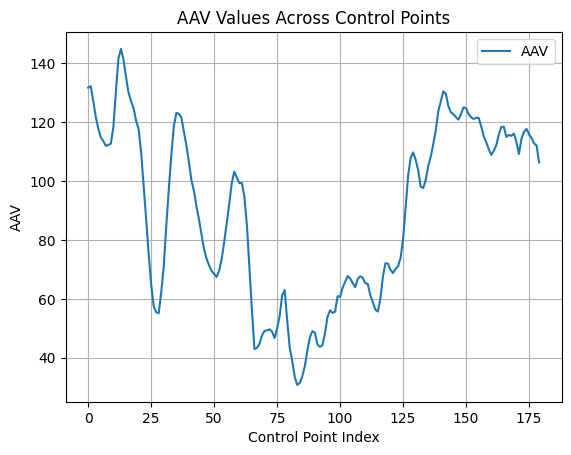

In [55]:
for i, val in enumerate(aav_list):
    if val < 0:
        print(f"AAV at CP {i} <0")
import matplotlib.pyplot as plt

plt.plot(aav_list, label="AAV")
plt.title("AAV Values Across Control Points")
plt.xlabel("Control Point Index")
plt.ylabel("AAV")
plt.grid(True)
plt.legend()
plt.show()


In [71]:
print("Raw CPs:", len(field1.cp))
print("Matrix columns:", field1.matrixA.shape[1])
print("AAV_cp:", field1.AAV_cp)
print("LSV_cp:", field1.LSV_cp)
print("MU weights:", len(field1.mu_weights))
print("MCS terms:", len(field1.MCS_terms))
print("MCS terms:", field1.MCS_arc)  # should be one less than CPs


Raw CPs: 180
Matrix columns: 180
AAV_cp: [0.5157223  0.51762731 0.49836288 0.47687197 0.46146519 0.44953506
 0.44462965 0.4383074  0.43960519 0.44124826 0.46367977 0.51036445
 0.55429878 0.56719332 0.55317958 0.53045042 0.50926907 0.49788663
 0.48852826 0.47214516 0.46058412 0.43028254 0.38647918 0.34121135
 0.29483623 0.25411661 0.22525569 0.21707605 0.21584969 0.24381764
 0.27860791 0.33203158 0.3808713  0.42593673 0.4644894  0.48208694
 0.48101537 0.47601472 0.45735751 0.43821215 0.41649502 0.3921585
 0.37824001 0.35740395 0.34025884 0.31998238 0.30092036 0.28832347
 0.27926276 0.27213087 0.26808273 0.26398695 0.27275    0.28802581
 0.31090976 0.33552013 0.36147591 0.38905095 0.40399338 0.39613521
 0.38874138 0.38889616 0.37079856 0.33307933 0.27583374 0.21967162
 0.16824822 0.16970079 0.17520151 0.18636964 0.1925014  0.19298956
 0.19448975 0.19123933 0.18284537 0.19593042 0.21188489 0.23963852
 0.24666325 0.20624129 0.17002226 0.15230566 0.13099334 0.12053959
 0.12313517 0.13205301

In [ ]:
# if you changed the code in field.py, run the above cell first
import os
from datetime import date

#datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\2024-1-02'

qadate = date(2024, 1, 2)
formatted_date = qadate.strftime("%Y-%m-%d")
datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date

# this specific format of the date is currently created in the __main__ of RetrieveFieldData.py
# TODO: change that


if not os.path.isdir(datafolder):
    formatted_date = f"{qadate.year}-{qadate.month}-{qadate.strftime('%d')}"
    datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date



# example of a Varian field: (field B2 for MRN 3102335 )
# ---------------------------
# filename = datafolder+'\\'+'FieldID_2406983.json' # make sure that this available locally on the computer (and not just in the cloud)

# in order to find that out, run the file RetrieveFieldData.py with the breakpoint() set 
# Q:\VMAT QA Project\Engineered Features>python RetrieveFieldData.py 2024 01 02 and then (Pdb) selection_augmented.query("FieldID == 2406983")


# example of an Elekta field (C2 for MRN 7211873):
# --------------------------
#filename = datafolder+'\\'+'FieldID_2406771.json'

# test field with 2 control points:
# -----------
filename = '/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/SimpleTestField.json'

field = Field(filename)
# %store field



In [ ]:

import numpy as np

#print(field.cp[0]['leafSetA'])
#print(field.cp[0]['leafSetB'])

#leafposA = field.cp[0]['leafSetA']

#print(field.mq_control_points[0]['leafSetA'][field.active_leaf_start:field.active_leaf_end])
#print(field.matrixA)

# for viewing in data wrangler:
Aside = field.matrixA
BSide = field.matrixB

leafgaps = Aside+BSide



leaf_widths = np.array(field.leaf_width[leafgaps.index.min()-1: leafgaps.index.max()-1+1]) 
# just leafs matching the dataframe leafgaps, leafgaps.index indicates the leaf number starting at 1, field.leaf_width starts at index 0, the +1 makes the second index inclusive! 


areas = leafgaps.mul(leaf_widths[:, np.newaxis])

#areas[:] = 1.0 # Just to see if the summation below makes sense! 

# This trick thanks to chatGPT
ranges = {col: (field.exposed_leaf_start[areas.columns.get_loc(col)], field.exposed_leaf_end[areas.columns.get_loc(col)]) for col in areas.columns}

sums = {col: areas[col].loc[start:end].sum() for col, (start, end) in ranges.items()}

print(areas.sum()) # This was Goerge's old code 




In [ ]:
### In this cell, we are testing the plotting capabilities
### -------------------------------------------------------
#from plotting_HK import plot_segment 
# # I changed Georg's original code to use the field as the first parameter, and not field_info which is not directly returned with Field()

# have to reimport this function whenever we change the function plot_segment()
import importlib
import plotting_HK
importlib.reload(plotting_HK)

from plotting_HK import plot_segment

segmentno = 0 # with 0 the first
plot_segment(field, segmentno)

print('Collimator X1 = ', field.cp[segmentno]['collimatorX1'])
print('Collimator X2 = ', field.cp[segmentno]['collimatorX2'])
print('Collimator Y1 = ', field.cp[segmentno]['collimatorY1'])
print('Collimator Y2 = ', field.cp[segmentno]['collimatorY2'])

print(field.exposed_leaf_start[segmentno])
print(field.exposed_leaf_end[segmentno])


print(field.matrixA.loc[field.exposed_leaf_start[segmentno]:field.exposed_leaf_end[segmentno], 
                        field.matrixA.columns[segmentno]])

print(field.collimatorAngle)
print(field.cp[segmentno]['spanMin'])
print(field.cp[segmentno]['spanMax'])


In [ ]:
import os
import pandas as pd

# Path to the file
file_path = "/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/SimpleTestField.json"

# Check the file exists before trying to read it
if not os.path.isfile(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

# Load the JSON file as a DataFrame (if it's structured like metadata)
df = pd.read_json(file_path)

# Display a preview
print(df.head())


In [ ]:
%reset -f